In [13]:
import Nodes
import numpy as np
import matplotlib.pyplot as plt
import aux_func as aux

r_teste = [-1.0, 0.0, 1.0, 0.5]
s_teste = [0.0, 0.5, 1.0, -1.0]

a_res, b_res = Nodes.rstoab(r_teste, s_teste)

print("Vetor r original:", r_teste)
print("Vetor s original:", s_teste)
print("-" * 30)
print("Resultado a:", a_res)
print("Resultado b:", b_res)

Vetor r original: [-1.0, 0.0, 1.0, 0.5]
Vetor s original: [0.0, 0.5, 1.0, -1.0]
------------------------------
Resultado a: [-1.   3.  -1.   0.5]
Resultado b: [ 0.   0.5  1.  -1. ]


--- Teste Numérico ---
Warp em r = -1.0 : 0.000000000000000 (Esperado: 0.0)
Warp em r =  1.0 : 0.000000000000000 (Esperado: 0.0)


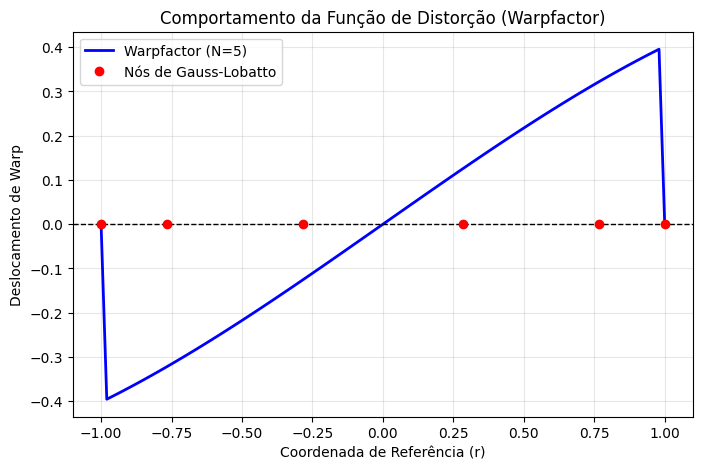

In [14]:
def testar_warpfactor():
    N = 5 

    pontos_criticos = np.array([-1.0, 0.0, 1.0])
    warp_critico = Nodes.Warpfactor(N, pontos_criticos)
    
    print("--- Teste Numérico ---")
    print(f"Warp em r = -1.0 : {warp_critico[0]:.15f} (Esperado: 0.0)")
    print(f"Warp em r =  1.0 : {warp_critico[2]:.15f} (Esperado: 0.0)")

    r_alta_resolucao = np.linspace(-1, 1, 100)
    warp_curva = Nodes.Warpfactor(N, r_alta_resolucao)
    
    plt.figure(figsize=(8, 5))
    plt.plot(r_alta_resolucao, warp_curva, 'b-', linewidth=2, label=f'Warpfactor (N={N})')
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    LGL_pontos = aux.JacobiGL(0, 0, N)
    plt.plot(LGL_pontos, np.zeros_like(LGL_pontos), 'ro', label='Nós de Gauss-Lobatto')
    
    plt.title("Comportamento da Função de Distorção (Warpfactor)")
    plt.xlabel("Coordenada de Referência (r)")
    plt.ylabel("Deslocamento de Warp")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

testar_warpfactor()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


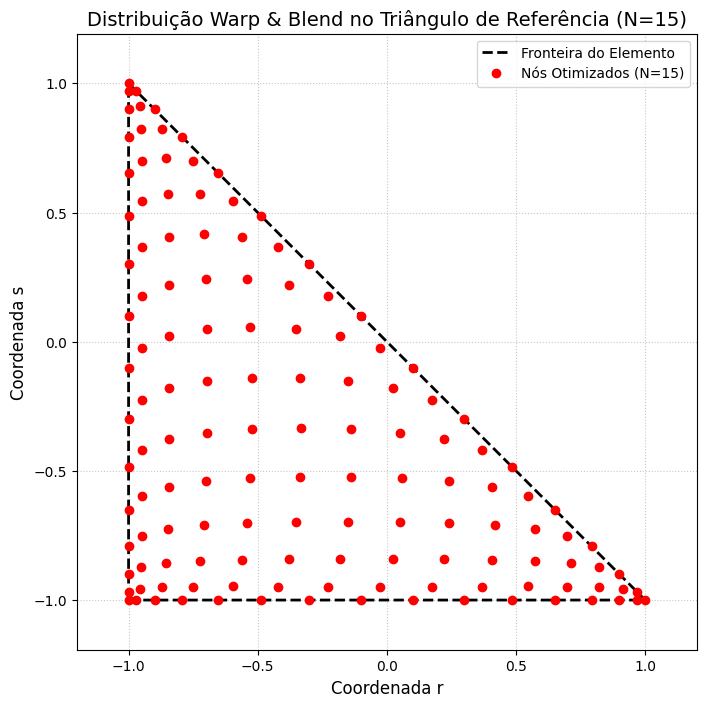

In [15]:
def plotar_malha_triangulo(N):
    # 1. Calcula os nós usando as suas funções corrigidas
    x, y = Nodes.Nodes2D(N)
    r, s = Nodes.xytors(x, y)
    
    # 2. Prepara a figura
    plt.figure(figsize=(8, 8))
    
    # 3. Desenha as bordas do triângulo de referência para checagem visual
    # Conecta os pontos: (-1,-1) -> (1,-1) -> (-1,1) -> volta pro (-1,-1)
    r_borda = [-1.0,  1.0, -1.0, -1.0]
    s_borda = [-1.0, -1.0,  1.0, -1.0]
    plt.plot(r_borda, s_borda, 'k--', linewidth=2, label='Fronteira do Elemento')
    
    # 4. Plota os nós que você calculou
    plt.plot(r, s, 'ro', markersize=6, label=f'Nós Otimizados (N={N})')
    
    # 5. Ajustes estéticos cruciais
    plt.axis('equal')  # Garante que as proporções geométricas sejam reais
    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    
    # Textos e legendas
    plt.title(f"Distribuição Warp & Blend no Triângulo de Referência (N={N})", fontsize=14)
    plt.xlabel("Coordenada r", fontsize=12)
    plt.ylabel("Coordenada s", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    
    plt.show()

# Faça o teste! Uma ordem N=6 ou N=8 costuma ficar com um visual bem legal.
plotar_malha_triangulo(N=15)

In [16]:
import numpy as np
import operators2D as op2D

def testar_condicao_vandermonde():
    print("Testando o Número de Condição da Matriz de Vandermonde 2D")
    print("-" * 55)
    print(f"{'Ordem (N)':<12} | {'Tamanho (Np)':<15} | {'Num. Condição':<20}")
    print("-" * 55)
    
    # Testa para ordens de 1 a 10
    for N in range(1, 11):
        # 1. Obtém os nós x, y otimizados (Warp & Blend)
        x, y = Nodes.Nodes2D(N)
        
        # 2. Transforma para as coordenadas do triângulo de referência r, s
        r, s = Nodes.xytors(x, y)
        
        # 3. Constrói a Matriz de Vandermonde 2D
        V = op2D.Vandermonde2D(N, r, s)
        
        # 4. Calcula o número de condição (razão entre maior e menor valor singular)
        cond_number = np.linalg.cond(V)
        
        # Tamanho do vetor (linhas/colunas da matriz quadrada V)
        Np = int((N + 1) * (N + 2) / 2)
        
        print(f"{N:<12} | {Np:<15} | {cond_number:<20.4f}")
        
    print("-" * 55)

# Executa o teste
testar_condicao_vandermonde()

Testando o Número de Condição da Matriz de Vandermonde 2D
-------------------------------------------------------
Ordem (N)    | Tamanho (Np)    | Num. Condição       
-------------------------------------------------------
1            | 3               | 2.0000              
2            | 6               | 4.1483              
3            | 10              | 5.9028              
4            | 15              | 6.7808              
5            | 21              | 8.0842              
6            | 28              | 9.5818              
7            | 36              | 11.2023             
8            | 45              | 13.9515             
9            | 55              | 17.0483             
10           | 66              | 21.7140             
-------------------------------------------------------


In [17]:
import numpy as np
import operators2D as op2D

def testar_matrizes_derivacao(N=3):
    print(f"--- Testando Matrizes D (Ordem N={N}) ---")
    
    # 1. Gera a malha e as coordenadas r, s
    x, y = Nodes.Nodes2D(N) # Ajuste para Nodes.Nodes2D se estiver em outro arquivo
    r, s = Nodes.xytors(x, y)
    
    # 2. Constrói a Matriz de Vandermonde e as Matrizes D
    V = op2D.Vandermonde2D(N, r, s)
    Dr, Ds =op2D.Dmatrices2D(N, r, s, V)
    
    # 3. Define a função de teste: f(r,s) = r^2 + s^3
    f_val = r**2 + s**3
    
    # 4. Derivadas Analíticas (Exatas)
    dfdr_exato = 2 * r
    dfds_exato = 3 * s**2
    
    # 5. Derivadas Numéricas (Usando as suas matrizes!)
    dfdr_num = Dr @ f_val
    dfds_num = Ds @ f_val
    
    # 6. Calcula o erro absoluto máximo entre a matriz e o cálculo exato
    erro_r = np.max(np.abs(dfdr_num - dfdr_exato))
    erro_s = np.max(np.abs(dfds_num - dfds_exato))
    
    print(f"Erro máximo na derivada em r (Dr): {erro_r:.3e}")
    print(f"Erro máximo na derivada em s (Ds): {erro_s:.3e}")

# Executa o teste
testar_matrizes_derivacao(N=3)

--- Testando Matrizes D (Ordem N=3) ---
Erro máximo na derivada em r (Dr): 1.332e-15
Erro máximo na derivada em s (Ds): 3.997e-15


In [18]:
import numpy as np

def testar_filtro2d(N=5, Nc=3, ordem_filtro=4):
    print(f"--- Testando Filtro 2D (N={N}, Corte Nc={Nc}) ---")
    
    # 1. Gera a malha geométrica
    x, y = Nodes.Nodes2D(N)
    r, s = Nodes.xytors(x, y)
    
    # 2. Matriz de Vandermonde e sua inversa
    V = op2D.Vandermonde2D(N, r, s)
    invV = np.linalg.inv(V)
    
    # 3. Constrói a Matriz de Filtro
    F = op2D.Filter2D(N, Nc, ordem_filtro, V)
    
    # 4. Cria um "sinal" ruidoso aleatório nos nós da malha
    np.random.seed(42) # Semente fixa para podermos reproduzir o mesmo teste
    u_nodal = np.random.rand(len(r))
    
    # 5. APLICA O FILTRO!
    u_filtrado = F @ u_nodal
    
    # 6. Analisando o resultado no Espaço Modal (Frequências)
    # Multiplicar por invV nos dá os coeficientes dos polinômios de Jacobi
    modos_originais = invV @ u_nodal
    modos_filtrados = invV @ u_filtrado
    
    # 7. Imprime a tabela de comparação
    print(f"\n{'Índice':<6} | {'Ordem (i+j)':<12} | {'Modo Original':<15} | {'Modo Filtrado':<15} | {'Atenuação'}")
    print("-" * 75)
    
    sk = 0
    for i in range(N + 1):
        for j in range(N - i + 1):
            ordem_modo = i + j
            orig = modos_originais[sk]
            filt = modos_filtrados[sk]
            
            # Calcula a porcentagem que restou do sinal
            if abs(orig) > 1e-14:
                razao = (filt / orig) * 100
            else:
                razao = 100.0
                
            # Destaca visualmente se o modo sofreu corte
            status = "Intacto" if ordem_modo < Nc else f"{razao:>6.2f}%"
            
            print(f"{sk:<6} | {ordem_modo:<12} | {orig:>15.4f} | {filt:>15.4f} | {status}")
            sk += 1

# Executa o teste
testar_filtro2d(N=5, Nc=3, ordem_filtro=4) 

--- Testando Filtro 2D (N=5, Corte Nc=3) ---

Índice | Ordem (i+j)  | Modo Original   | Modo Filtrado   | Atenuação
---------------------------------------------------------------------------
0      | 0            |          0.7824 |          0.7824 | Intacto
1      | 1            |         -0.1415 |         -0.1415 | Intacto
2      | 2            |         -0.0279 |         -0.0279 | Intacto
3      | 3            |          0.0760 |          0.0760 | 100.00%
4      | 4            |          0.0157 |          0.0016 |  10.51%
5      | 5            |         -0.0106 |         -0.0000 |   0.00%
6      | 1            |         -0.1951 |         -0.1951 | Intacto
7      | 2            |         -0.0997 |         -0.0997 | Intacto
8      | 3            |          0.0869 |          0.0869 | 100.00%
9      | 4            |          0.0756 |          0.0080 |  10.51%
10     | 5            |         -0.0926 |          0.0000 |  -0.00%
11     | 2            |         -0.0529 |         -0.0529 | 

In [19]:
def testar_lift2d(N=4):
    print(f"--- Testando Matriz LIFT (Ordem N={N}) ---")
    
    # 1. Gera a geometria básica
    # (Ajuste para Nodes.Nodes2D, etc., dependendo de como você organizou os arquivos)
    x, y = Nodes.Nodes2D(N)
    r, s = Nodes.xytors(x, y)
    Fmask = op2D.calcular_fmask(r, s)
    
    # 2. Constrói a Matriz de Vandermonde e a Matriz de Massa 2D
    V = op2D.Vandermonde2D(N, r, s)
    M = np.linalg.inv(V @ V.T)  # Matriz de Massa do Volume
    
    # 3. Calcula a Matriz LIFT usando a função que corrigimos
    LIFT = op2D.Lift2D(N, r, s, V, Fmask)
    
    # 4. O TESTE DO TEOREMA DE GAUSS
    Nfp = N + 1
    # Cria um vetor de "1"s representando um fluxo constante e unitário nas 3 faces
    fluxo_faces = np.ones(3 * Nfp)
    
    # "Levanta" esse fluxo das bordas para o volume do triângulo
    fluxo_volume = LIFT @ fluxo_faces
    
    # Integra o fluxo levantado em todo o volume do triângulo
    # Em métodos espectrais, multiplicar por M e somar tudo é o equivalente numérico de ∫f(x)dx
    integral_volume = np.sum(M @ fluxo_volume)
    
    # 5. Exibe os resultados
    print(f"Integral de Volume Computada : {integral_volume:.14f}")
    print(f"Valor Analítico Esperado     : 6.00000000000000")
    
    erro = abs(integral_volume - 6.0)
    print(f"Erro Absoluto                : {erro:.3e}")


# Executa o teste
testar_lift2d(N=4)

--- Testando Matriz LIFT (Ordem N=4) ---
Integral de Volume Computada : 6.00000000000000
Valor Analítico Esperado     : 6.00000000000000
Erro Absoluto                : 0.000e+00


In [20]:
import numpy as np

def testar_operadores_vetoriais(N=3):
    print(f"--- Testando Gradiente, Divergente e Rotacional (Ordem N={N}) ---")
    
    # 1. Gera malha e coordenadas
    # (Usaremos x=r e y=s para testar no próprio triângulo de referência)
    x, y = Nodes.Nodes2D(N) 
    r, s = Nodes.xytors(x, y)
    
    # 2. Matrizes Básicas
    V = op2D.Vandermonde2D(N, r, s)
    Dr, Ds = op2D.Dmatrices2D(N, r, s, V)
    
    # 3. Fatores Geométricos
    # Se você ainda não implementou aquela função GeometricFactors2D, 
    # podemos usar a versão analítica do triângulo de referência:
    rx = np.ones_like(r)
    sy = np.ones_like(s)
    sx = np.zeros_like(s)
    ry = np.zeros_like(r)
    
# ==========================================
    # TESTE 1: GRADIENTE (Grad2D)
    # Mudamos x e y para r e s
    # ==========================================
    u_campo = r**2 + s**3
    ux_exato = 2 * r
    uy_exato = 3 * s**2
    
    ux_num, uy_num = op2D.Grad2D(u_campo, rx, sx, ry, sy, Dr, Ds)
    
    erro_grad_x = np.max(np.abs(ux_num - ux_exato))
    erro_grad_y = np.max(np.abs(uy_num - uy_exato))
    
    # ==========================================
    # TESTE 2 e 3: DIVERGENTE E ROTACIONAL
    # ==========================================
    vx_campo = (r**2) * s
    vy_campo = r * (s**2)
    
    div_exato = 4 * r * s
    curl_z_exato = s**2 - r**2
    
    div_num = op2D.Div2D(vx_campo, vy_campo, rx, sx, ry, sy, Dr, Ds)
    _, _, curl_z_num = op2D.Curl2D(vx_campo, vy_campo, None, rx, sx, ry, sy, Dr, Ds) 
    
    erro_div = np.max(np.abs(div_num - div_exato))
    erro_curl = np.max(np.abs(curl_z_num - curl_z_exato))
    
    # ==========================================
    # RESULTADOS
    # ==========================================
    print(f"Erro Gradiente (eixo X) : {erro_grad_x:.3e}")
    print(f"Erro Gradiente (eixo Y) : {erro_grad_y:.3e}")
    print(f"Erro Divergente         : {erro_div:.3e}")
    print(f"Erro Rotacional (eixo Z): {erro_curl:.3e}")

testar_operadores_vetoriais(N=3)

--- Testando Gradiente, Divergente e Rotacional (Ordem N=3) ---
Erro Gradiente (eixo X) : 1.332e-15
Erro Gradiente (eixo Y) : 3.997e-15
Erro Divergente         : 1.776e-15
Erro Rotacional (eixo Z): 1.776e-15


In [21]:
import grid

def testar_geometria(N=3):
    print(f"--- Testando Fatores Geométricos e Normais (Ordem N={N}) ---")
    
    # 1. Gera a base geométrica
    x_nodes, y_nodes = Nodes.Nodes2D(N)
    r, s = Nodes.xytors(x_nodes, y_nodes)
    
    # Vamos forçar a malha física a ser exatamente o triângulo de referência
    # E adicionamos [:, None] para simular uma malha de K=1 triângulos
    x = r[:, None] 
    y = s[:, None]
    
    # Matrizes D e Fmask
    V = op2D.Vandermonde2D(N, r, s)
    Dr, Ds = op2D.Dmatrices2D(N, r, s, V)
    Fmask = op2D.calcular_fmask(r, s)
    Nfp = N + 1
    
    # ==========================================
    # TESTE 1: Fatores Geométricos
    # ==========================================
    rx, sx, ry, sy, J = grid.GeometricFactors2D(x, y, Dr, Ds)
    
    # Verifica se rx=1, sy=1, sx=0, ry=0 e J=1
    erro_geom = max(
        np.max(np.abs(rx - 1.0)),
        np.max(np.abs(sy - 1.0)),
        np.max(np.abs(sx - 0.0)),
        np.max(np.abs(ry - 0.0)),
        np.max(np.abs(J - 1.0))
    )
    
    # ==========================================
    # TESTE 2: Vetores Normais
    # ==========================================
    nx, ny, sJ = grid.Normals2D(x, y, Dr, Ds, Fmask, N)
    
    # Pega apenas um nó de cada face (o primeiro de cada) para verificar a direção
    # Como as faces são retas, a normal é igual em todos os nós daquela face
    idx_face1 = 0
    idx_face2 = Nfp
    idx_face3 = 2 * Nfp
    
    print("\n[VETORES NORMAIS (nx, ny)]")
    print(f"Face 1 (Inferior) : ({nx[idx_face1, 0]:.3f}, {ny[idx_face1, 0]:.3f}) -> Esperado: ( 0.000, -1.000)")
    print(f"Face 2 (Diagonal) : ({nx[idx_face2, 0]:.3f}, {ny[idx_face2, 0]:.3f}) -> Esperado: ( 0.707,  0.707)")
    print(f"Face 3 (Esquerda) : ({nx[idx_face3, 0]:.3f}, {ny[idx_face3, 0]:.3f}) -> Esperado: (-1.000,  0.000)")
    
    print("\n[JACOBIANOS DE SUPERFÍCIE (sJ)]")
    print(f"Face 1 sJ: {sJ[idx_face1, 0]:.3f} -> Esperado: 1.000")
    print(f"Face 2 sJ: {sJ[idx_face2, 0]:.3f} -> Esperado: 1.414 (Raiz de 2)")
    print(f"Face 3 sJ: {sJ[idx_face3, 0]:.3f} -> Esperado: 1.000")

testar_geometria(N=3)

--- Testando Fatores Geométricos e Normais (Ordem N=3) ---

[VETORES NORMAIS (nx, ny)]
Face 1 (Inferior) : (-0.000, -1.000) -> Esperado: ( 0.000, -1.000)
Face 2 (Diagonal) : (0.707, 0.707) -> Esperado: ( 0.707,  0.707)
Face 3 (Esquerda) : (-1.000, -0.000) -> Esperado: (-1.000,  0.000)

[JACOBIANOS DE SUPERFÍCIE (sJ)]
Face 1 sJ: 1.000 -> Esperado: 1.000
Face 2 sJ: 1.414 -> Esperado: 1.414 (Raiz de 2)
Face 3 sJ: 1.000 -> Esperado: 1.000


In [22]:
import numpy as np
import setup as stp
import grid

# =========================================================
# 1. A Malha de Laboratório (Apenas 2 Triângulos)
# =========================================================
# Vértices de um quadrado perfeito [0,1]x[0,1]
VX = np.array([0.0, 1.0, 1.0, 0.0])
VY = np.array([0.0, 0.0, 1.0, 1.0])

# Triângulo 0 liga os nós: 0 -> 1 -> 2
# Triângulo 1 liga os nós: 0 -> 2 -> 3
EToV = np.array([[0, 1, 2],
                 [0, 2, 3]])

# =========================================================
# 2. Testando o Connect2D (Quem é vizinho de quem?)
# =========================================================
EToE, EToF = grid.Connect2D(EToV)

print("--- TESTE 1: Connect2D ---")
print("EToE (Elemento para Elemento):")
print(EToE)
print("\nEToF (Elemento para Face):")
print(EToF)

# =========================================================
# 3. Testando o BuildMaps2D (A Prova Definitiva)
# =========================================================
# Usamos N=1 para ter apenas 3 nós por triângulo (fica fácil de ler)
N = 1 
malha = stp.StartUp2D(N, EToV, VX, VY)

print("\n--- TESTE 2: BuildMaps2D ---")
# O teste de ouro: O Salto das Coordenadas (Coordinate Jump)
# Se o vmapM (lado de dentro) e o vmapP (lado de fora/vizinho) estiverem 
# perfeitamente alinhados, as coordenadas (x,y) de ambos PRECISAM ser iguais!

dx = malha.x.flatten(order='F')[malha.vmapM] - malha.x.flatten(order='F')[malha.vmapP]
dy = malha.y.flatten(order='F')[malha.vmapM] - malha.y.flatten(order='F')[malha.vmapP]

erro_maximo_x = np.max(np.abs(dx))
erro_maximo_y = np.max(np.abs(dy))

print(f"Erro máximo de alinhamento em X: {erro_maximo_x}")
print(f"Erro máximo de alinhamento em Y: {erro_maximo_y}")

--- TESTE 1: Connect2D ---
EToE (Elemento para Elemento):
[[0 0 1]
 [0 1 1]]

EToF (Elemento para Face):
[[0 1 0]
 [2 1 2]]

--- TESTE 2: BuildMaps2D ---
Erro máximo de alinhamento em X: 0.0
Erro máximo de alinhamento em Y: 0.0


Malha carregada com sucesso!
Número de vértices: 441
Número de Elementos (K): 800
Tempo atual: 8.3200e-03 / 5.0000e+00
Tempo atual: 1.6640e-02 / 5.0000e+00
Tempo atual: 2.4960e-02 / 5.0000e+00
Tempo atual: 3.3280e-02 / 5.0000e+00
Tempo atual: 4.1600e-02 / 5.0000e+00
Tempo atual: 4.9920e-02 / 5.0000e+00
Tempo atual: 5.8240e-02 / 5.0000e+00
Tempo atual: 6.6560e-02 / 5.0000e+00
Tempo atual: 7.4880e-02 / 5.0000e+00
Tempo atual: 8.3200e-02 / 5.0000e+00
Tempo atual: 9.1520e-02 / 5.0000e+00
Tempo atual: 9.9840e-02 / 5.0000e+00
Tempo atual: 1.0816e-01 / 5.0000e+00
Tempo atual: 1.1648e-01 / 5.0000e+00
Tempo atual: 1.2480e-01 / 5.0000e+00
Tempo atual: 1.3312e-01 / 5.0000e+00
Tempo atual: 1.4144e-01 / 5.0000e+00
Tempo atual: 1.4976e-01 / 5.0000e+00
Tempo atual: 1.5808e-01 / 5.0000e+00
Tempo atual: 1.6640e-01 / 5.0000e+00
Tempo atual: 1.7472e-01 / 5.0000e+00
Tempo atual: 1.8304e-01 / 5.0000e+00
Tempo atual: 1.9136e-01 / 5.0000e+00
Tempo atual: 1.9968e-01 / 5.0000e+00
Tempo atual: 2.0800e-01 / 5.00

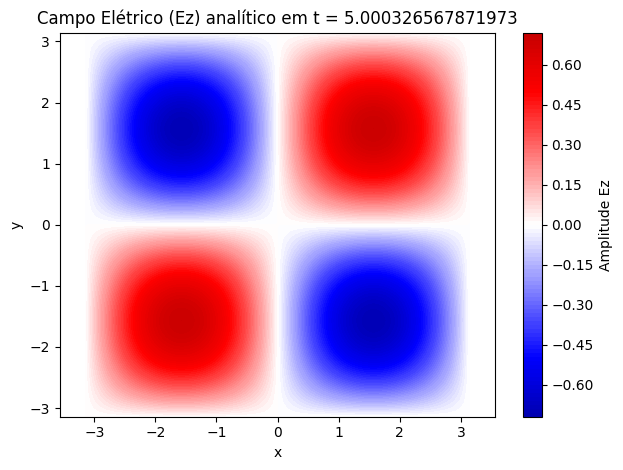

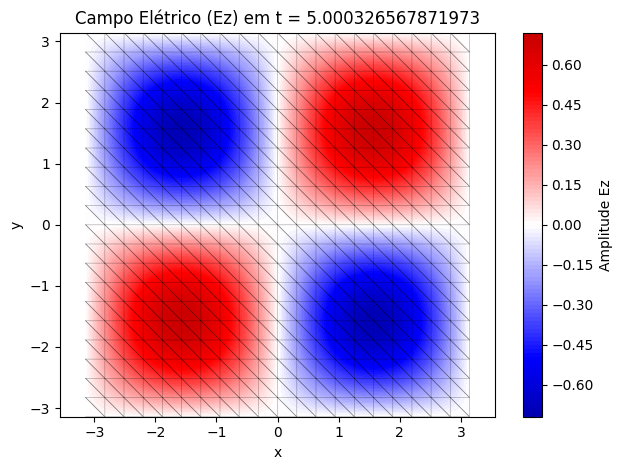

--- Análise de Erro (t = 5.0003) ---
Norma L-infinito (Máx): 3.7061e-08
Norma L2 Relativa:      2.5293e-08


Erro L2 Contínuo (Real): 2.5293e-08
Erro L2 Contínuo (Massa Exata): 9.7182e-09


In [23]:
import numpy as np
import setup as stp
import Maxwell2D as Max
import mesh_reader as msh
import matplotlib.pyplot as plt

N =  5

VX, VY, EToV, BCTags = msh.MeshReader2D('malhas/pi.msh')

malha = stp.StartUp2D(N,EToV,VX,VY)

### Condições iniciais
Ez = np.zeros((malha.Np,malha.K),dtype=np.float64)
Ez = np.sin(malha.x)*np.sin(malha.y)
#Ez = np.zeros((malha.Np,malha.K))
#Ez = np.exp(-(malha.x**2 + malha.y**2) / (0.1**2))
Hx = np.zeros((malha.Np,malha.K), dtype=np.float64)
Hy = np.zeros((malha.Np,malha.K),dtype= np.float64)

FinalTime = 5
Hx, Hy, Ez, pp, t, erro = Max.Maxwell2D(Hx,Hy,Ez,FinalTime,malha)

x_plot = malha.x.flatten(order='F')
y_plot = malha.y.flatten(order='F')
Ez_plot = Ez.flatten(order='F')

######## Solução teórica

Ez_analitico = np.sin(malha.x)*np.sin(malha.y)*np.cos(np.sqrt(2)*t[-1])

x_plot2 = malha.x.flatten(order='F')
y_plot2 = malha.y.flatten(order='F')
Ez_plot2 = Ez_analitico.flatten(order='F')

plt.figure()
plt.title(f'Campo Elétrico (Ez) analítico em t = {t[-1]}')

grafico = plt.tricontourf(x_plot2, y_plot2, Ez_plot2, levels=100, cmap='seismic',vmin=-1,vmax=1)
plt.colorbar(grafico, label='Amplitude Ez')

plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()

plt.show()

vmin = np.min(Ez_plot2)
vmax = np.max(Ez_plot2)

plt.figure()
plt.title(f'Campo Elétrico (Ez) em t = {t[-1]}')

grafico = plt.tricontourf(x_plot, y_plot, Ez_plot, levels=100, cmap='seismic',vmin=-1,vmax=1)
plt.colorbar(grafico, label='Amplitude Ez')

plt.plot(VX[EToV].T, VY[EToV].T, color='k', linewidth=0.5, alpha=0.3)

plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()

plt.show()

# 2. Norma L-infinito (Erro Máximo Absoluto)
# Ótimo para ver se existe algum "pico" de erro escondido em algum triângulo
erro_Linf = np.max(np.abs(Ez - Ez_analitico))

# 3. Norma L2 Relativa (A mais usada em artigos científicos)
# Mostra o erro percentual global de energia na malha
erro_L2 = np.linalg.norm(Ez - Ez_analitico) / np.linalg.norm(Ez_analitico)

print(f"--- Análise de Erro (t = {t[-1]:.4f}) ---")
print(f"Norma L-infinito (Máx): {erro_Linf:.4e}")
print(f"Norma L2 Relativa:      {erro_L2:.4e}")

print('\n')

erro_quadrado = (Ez - Ez_analitico)**2
integral_erro = np.sum(malha.J * erro_quadrado) 
En = np.sqrt(integral_erro)

analitico_quadrado = Ez_analitico**2
integral_analitico = np.sum(malha.J * analitico_quadrado)
wt = np.sqrt(integral_analitico)

erro_L2_real = En / wt

print(f"Erro L2 Contínuo (Real): {erro_L2_real:.4e}")

# 1. Recuperamos a Matriz de Massa do triângulo de referência.
# Se o seu 'setup.py' não exporta a matriz M, nós calculamos ela aqui na hora
# usando a Matriz de Vandermonde (V): M = (V * V^T)^-1
M = np.linalg.inv(malha.V @ malha.V.T) 

# 2. O vetor de diferença nodal
erro_nodal = Ez - Ez_analitico

# 3. Integração Exata de Galerkin para o Numerador (Erro)
# (M @ erro_nodal) aplica os pesos da matriz de massa.
# erro_nodal * (...) faz o produto ponto a ponto (e^T * M * e).
# malha.J faz o escalonamento da área para o triângulo físico.
integral_erro_sq = np.sum(malha.J * (erro_nodal * (M @ erro_nodal)))
En = np.sqrt(integral_erro_sq)

# 4. Integração Exata para o Denominador (Analítico)
integral_analitico_sq = np.sum(malha.J * (Ez_analitico * (M @ Ez_analitico)))
wt = np.sqrt(integral_analitico_sq)

# 5. Erro Relativo Final
erro_L2_real = En / wt

print(f"Erro L2 Contínuo (Massa Exata): {erro_L2_real:.4e}")

Nó mais próximo encontrado em x = 0.49751, y = 0.49751


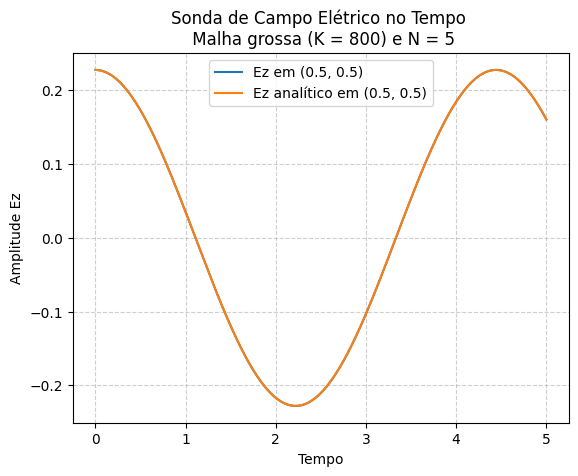

In [24]:
# 1. Defina o ponto onde você quer colocar a "sonda"
x_alvo = 0.5
y_alvo = 0.5

# 2. Calcula a distância geométrica de TODOS os nós para o alvo
distancias = np.sqrt((malha.x - x_alvo)**2 + (malha.y - y_alvo)**2)

# 3. Encontra o índice linear do nó mais próximo
indice_linear_mais_proximo = np.argmin(distancias)

# 4. Converte o índice linear de volta para as dimensões (Nó, Triângulo)
no_idx, tri_idx = np.unravel_index(indice_linear_mais_proximo, malha.x.shape)

print(f"Nó mais próximo encontrado em x = {malha.x[no_idx, tri_idx]:.5f}, y = {malha.y[no_idx, tri_idx]:.5f}")

# 5. Converte a sua lista do tempo para array do Numpy
pp_array = np.array(pp)
Ez_analiticot = np.zeros(len(t))
for n in range(len(t)):
    Ez_analiticot[n] = np.sin(malha.x[no_idx, tri_idx])*np.sin(malha.y[no_idx, tri_idx])*np.cos(np.sqrt(2)*t[n])
# 6. Extrai e plota a onda exatamente nesse nó ao longo de todo o tempo
plt.figure()
plt.plot(t, pp_array[:, no_idx, tri_idx], label=f'Ez em ({x_alvo}, {y_alvo})')
plt.plot(t,Ez_analiticot,label=f'Ez analítico em ({x_alvo}, {y_alvo})')

plt.title(f'Sonda de Campo Elétrico no Tempo \n Malha grossa (K = {malha.K}) e N = {N}')
plt.xlabel('Tempo')
plt.ylabel('Amplitude Ez')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

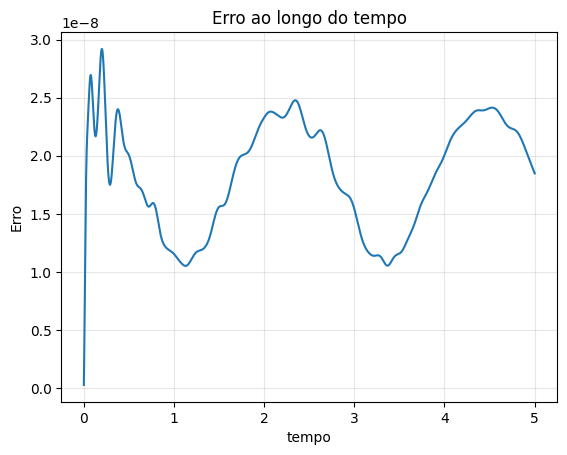

In [25]:
plt.figure()
plt.grid(alpha=0.3)
plt.title('Erro ao longo do tempo')
plt.plot(t,erro)
plt.xlabel('tempo')
plt.ylabel('Erro')
plt.show()